## UNSW-NB15 — Simple Multi-Task Classification Pipeline

### Targets
- **`label`**: binary classification (0 = no attack, 1 = attack)
- **`attack_cat`**: multi-class classification (type of attack)

### What you’ll get
- Basic dataset exploration (types, missing values, imbalance, quick distributions)
- Simple cleaning + preprocessing (duplicates, missing values, categorical encoding)
- Minimal feature selection (drop ID-like columns, variance + correlation filtering)
- Two tuned model families compared per target (Random Forest vs Gradient Boosting)
- Clear evaluation (accuracy, precision/recall/F1, confusion matrices)
- Saved artifacts in `training/Processed_Dataset/` (processed CSV + trained models)



In [1]:
from __future__ import annotations

import json
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight

RANDOM_STATE = 42
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

# Handle running from project root vs notebook directory
if Path("Dataset").exists():
    DATA_DIR = Path("Dataset")
    OUT_DIR = Path("Processed_Dataset")
else:
    DATA_DIR = Path("training/Dataset")
    OUT_DIR = Path("training/Processed_Dataset")

OUT_DIR.mkdir(parents=True, exist_ok=True)

# If your machine struggles with RAM, set this to a smaller value (e.g. 300_000).
# Keeping it None loads all rows.
MAX_ROWS_TO_LOAD = None

# Tuning can be slow on very large datasets; this keeps the demo practical.
# Set to None to train on the full dataset.
MAX_ROWS_FOR_MODELING = 250_000

print("DATA_DIR:", DATA_DIR.resolve())
print("OUT_DIR:", OUT_DIR.resolve())



DATA_DIR: C:\Users\rhmar\GitHub\CTD-Project\training\Dataset
OUT_DIR: C:\Users\rhmar\GitHub\CTD-Project\training\Processed_Dataset


### 1) Load dataset (using the official feature list)

The `UNSW-NB15_*.csv` files are **headerless** in this folder, so we load the column names from `NUSW-NB15_features.csv` and apply them when reading each part.


In [2]:
features_path = DATA_DIR / "NUSW-NB15_features.csv"
parts = sorted(DATA_DIR.glob("UNSW-NB15_*.csv"))

assert features_path.exists(), f"Missing: {features_path}"
assert parts, f"No dataset parts found in {DATA_DIR}"

features_df = pd.read_csv(features_path, encoding='cp1252')
features_df.columns = [c.strip() for c in features_df.columns]

raw_feature_names = features_df["Name"].astype(str).tolist()
raw_feature_types = features_df["Type"].astype(str).str.strip().str.lower().tolist()

# Clean column names for easier use (and to ensure the targets are exactly 'label' and 'attack_cat')
def clean_col(name: str) -> str:
    name = name.strip().lower()
    name = "".join(ch if ch.isalnum() else "_" for ch in name)
    while "__" in name:
        name = name.replace("__", "_")
    return name.strip("_")

col_names = [clean_col(n) for n in raw_feature_names]

# Ensure target naming matches the objectives
col_names = ["label" if c == "label" or c == "lab" or c == "label_" else c for c in col_names]
# In the metadata this column is 'Label' → becomes 'label' after cleaning; keep it.

print("Columns (count):", len(col_names))
print("Last columns:", col_names[-3:])

# Build a simple type map from the feature metadata
# (nominal → categorical, integer/float/binary → numeric)
type_map = {}
for name, t in zip(col_names, raw_feature_types):
    if "nominal" in t:
        type_map[name] = "categorical"
    elif "int" in t or "float" in t or "binary" in t:
        type_map[name] = "numeric"
    else:
        type_map[name] = "unknown"

# Sanity-check targets exist
assert "label" in col_names, "Target 'label' not found in feature names"
assert "attack_cat" in col_names, "Target 'attack_cat' not found in feature names"



Columns (count): 49
Last columns: ['ct_dst_src_ltm', 'attack_cat', 'label']


In [3]:
na_values = ["", " ", "  ", "   "]  # treat empty/blank as missing; '-' is a valid category here

dfs = []
for p in parts:
    print("Loading:", p.name)
    part_df = pd.read_csv(
        p,
        header=None,
        names=col_names,
        na_values=na_values,
        keep_default_na=True,
        low_memory=False,
        nrows=MAX_ROWS_TO_LOAD,
    )
    dfs.append(part_df)

df = pd.concat(dfs, ignore_index=True)

# Convert numeric columns based on metadata
numeric_cols_by_meta = [c for c in col_names if type_map.get(c) == "numeric"]
cat_cols_by_meta = [c for c in col_names if type_map.get(c) == "categorical"]

for c in numeric_cols_by_meta:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# Keep categorical as strings (helps consistent handling of missing values)
for c in cat_cols_by_meta:
    df[c] = df[c].astype("string")

print("\nDataset shape:", df.shape)
df.head()


Loading: UNSW-NB15_1.csv
Loading: UNSW-NB15_2.csv
Loading: UNSW-NB15_3.csv
Loading: UNSW-NB15_4.csv

Dataset shape: (2540047, 49)


,srcip,sport,dstip,dsport,proto,state,dur,sbytes,dbytes,sttl,...,ct_ftp_cmd,ct_srv_src,ct_srv_dst,ct_dst_ltm,ct_src_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,attack_cat,label
0,59.166.0.0,1390.0,149.171.126.6,53.0,udp,CON,0.001055,132,164,31,...,0.0,3,7,1,3,1,1,1,<NA>,0
1,59.166.0.0,33661.0,149.171.126.9,1024.0,udp,CON,0.036133,528,304,31,...,0.0,2,4,2,3,1,1,2,<NA>,0
2,59.166.0.6,1464.0,149.171.126.7,53.0,udp,CON,0.001119,146,178,31,...,0.0,12,8,1,2,2,1,1,<NA>,0
3,59.166.0.5,3593.0,149.171.126.5,53.0,udp,CON,0.001209,132,164,31,...,0.0,6,9,1,1,1,1,1,<NA>,0
4,59.166.0.3,49664.0,149.171.126.0,53.0,udp,CON,0.001169,146,178,31,...,0.0,7,9,1,1,1,1,1,<NA>,0


### 2) Quick exploration (types, missing values, duplicates, class imbalance)

We’ll keep exploration lightweight and practical:
- Verify data types
- Check missing values + duplicates
- Inspect target distributions (`label`, `attack_cat`)


int64             28
float64           15
string[python]     6
Name: count, dtype: int64

Top missing columns:


,missing_fraction
attack_cat,0.873513
ct_ftp_cmd,0.562934
is_ftp_login,0.562934
ct_flw_http_mthd,0.530756
dsport,0.000120
sport,0.000003
srcip,0.000000
dstip,0.000000
proto,0.000000
sttl,0.000000



Duplicate rows: 480,633 (18.9222%)

'label' distribution:


,count
label,
0,2218764
1,321283



'attack_cat' distribution (including missing):


,count
attack_cat,
<NA>,2218764
Generic,215481
Exploits,44525
Fuzzers,19195
DoS,16353
Reconnaissance,12228
Fuzzers,5051
Analysis,2677
Backdoor,1795


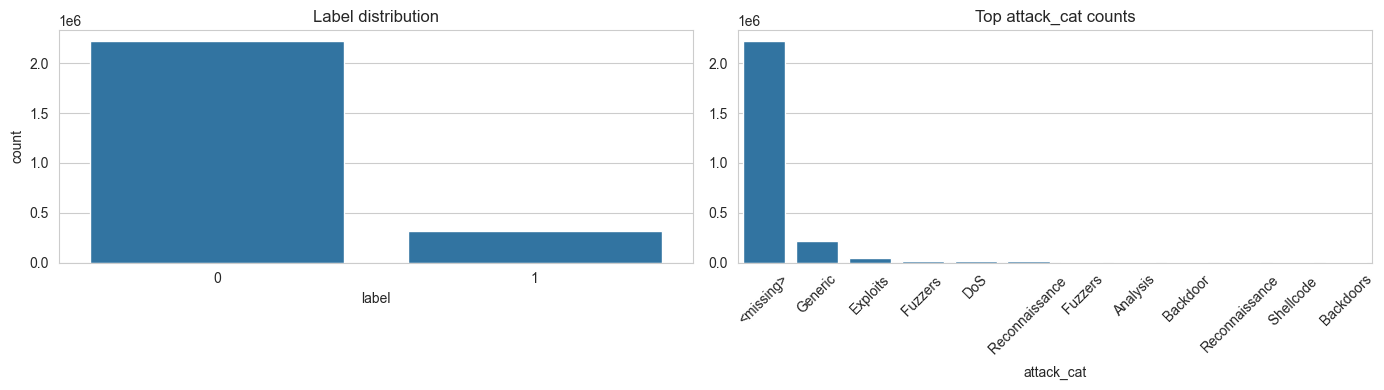

In [4]:
# Data types overview
print(df.dtypes.value_counts())

# Missing values (top 20)
missing_frac = (df.isna().mean().sort_values(ascending=False))
print("\nTop missing columns:")
display(missing_frac.head(20).to_frame("missing_fraction"))

# Duplicates
n_dupes = df.duplicated().sum()
print(f"\nDuplicate rows: {n_dupes:,} ({n_dupes / len(df):.4%})")

# Targets
print("\n'label' distribution:")
display(df["label"].value_counts(dropna=False).to_frame("count"))

print("\n'attack_cat' distribution (including missing):")
display(df["attack_cat"].value_counts(dropna=False).head(20).to_frame("count"))

# Simple plots
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.countplot(x="label", data=df, ax=axes[0])
axes[0].set_title("Label distribution")

attack_counts = df["attack_cat"].fillna("<missing>").value_counts().head(12)
sns.barplot(x=attack_counts.index, y=attack_counts.values, ax=axes[1])
axes[1].set_title("Top attack_cat counts")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


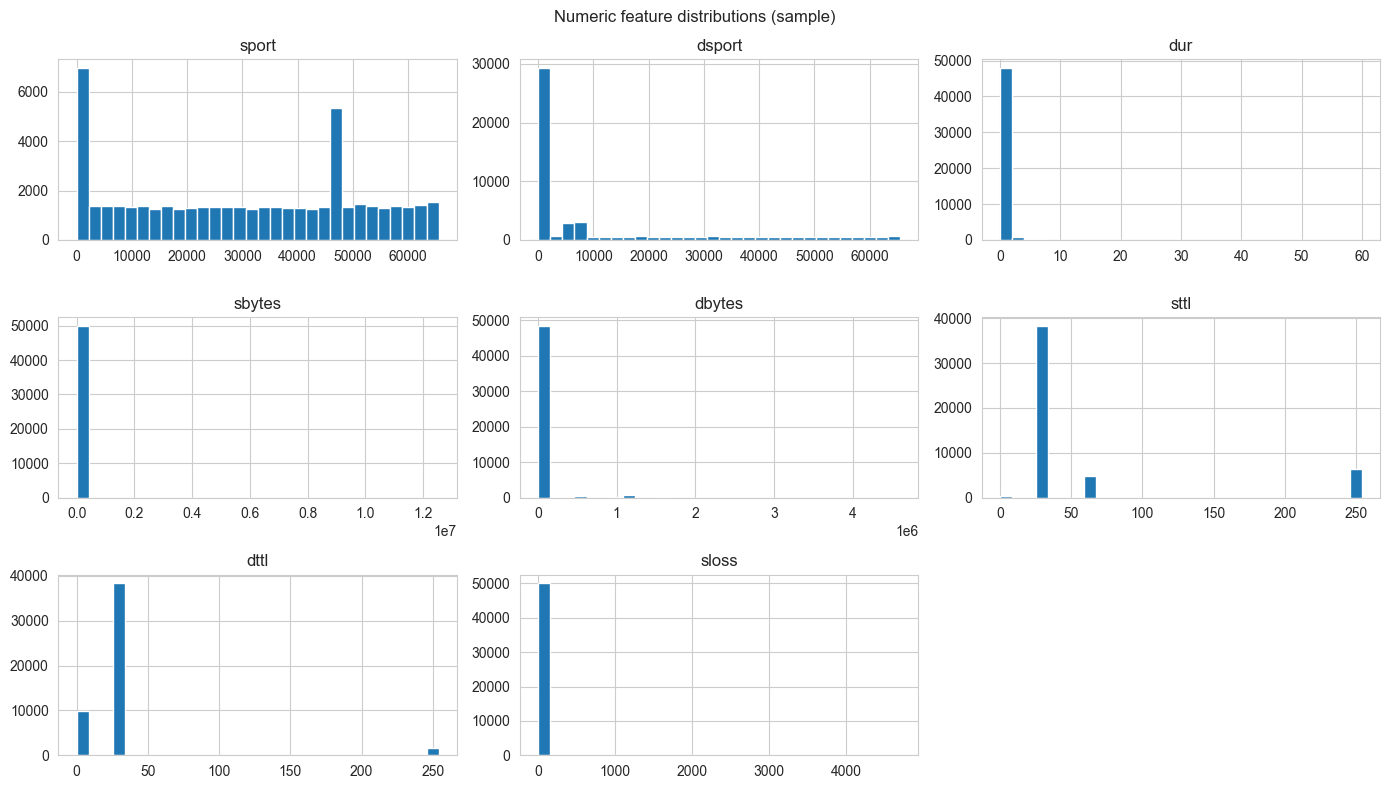

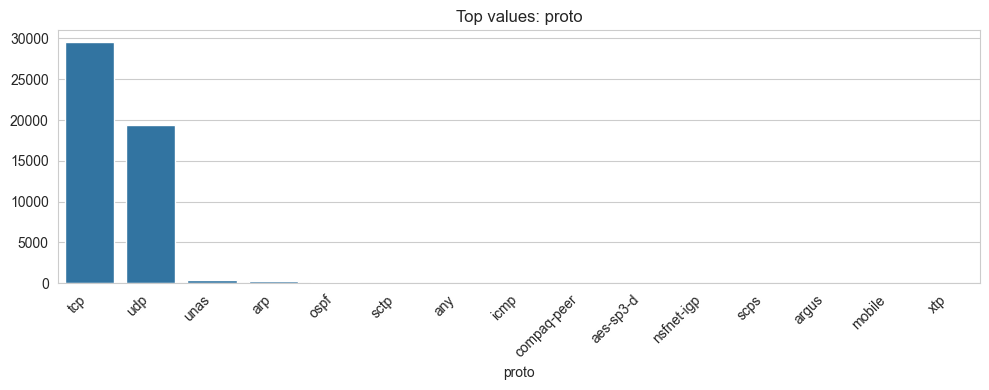

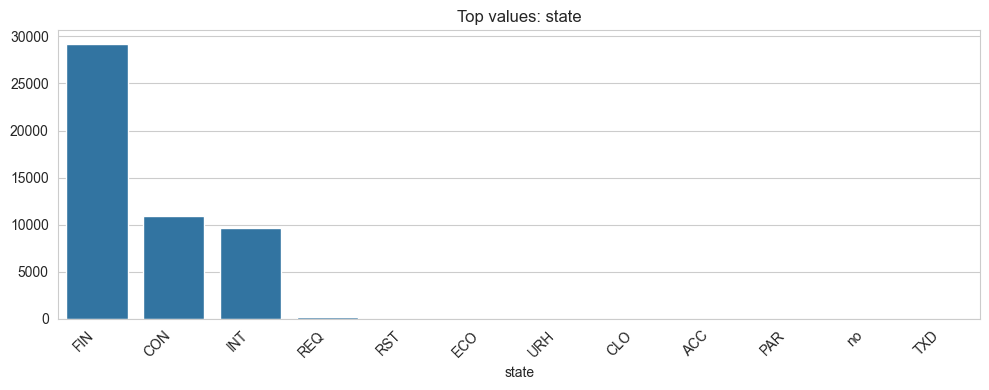

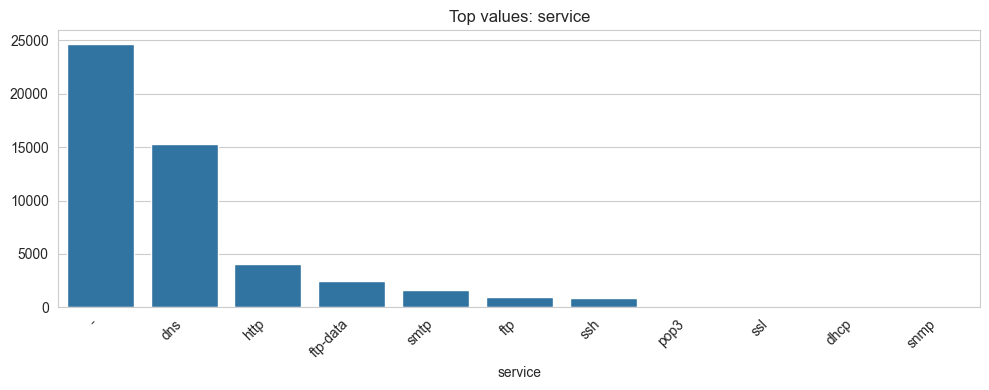

In [5]:
# Basic feature distributions (sampled for speed)
eda_sample = df.sample(n=min(50_000, len(df)), random_state=RANDOM_STATE)

# Numeric distributions (show a handful)
num_candidates = [c for c in numeric_cols_by_meta if c not in {"label"}]
num_show = num_candidates[:8]

eda_sample[num_show].hist(bins=30, figsize=(14, 8))
plt.suptitle("Numeric feature distributions (sample)")
plt.tight_layout()
plt.show()

# Categorical distributions (common columns in UNSW-NB15)
for c in ["proto", "state", "service"]:
    if c in eda_sample.columns:
        vc = eda_sample[c].fillna("<missing>").value_counts().head(15)
        plt.figure(figsize=(10, 4))
        sns.barplot(x=vc.index.astype(str), y=vc.values)
        plt.title(f"Top values: {c}")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()


### 3) Cleaning + minimal feature selection

We keep this step simple and explainable:
- Remove duplicate rows
- Fix missing `attack_cat` for normal traffic (treat as **`Normal`**)
- Drop ID-like / leakage-prone columns (IP addresses, raw timestamps)
- Drop zero-variance numeric features
- Drop one of each pair of highly-correlated numeric features (to reduce redundancy)


In [6]:
dropped_features = []  # list[dict]

def drop_cols(cols, reason: str):
    global df
    cols = [c for c in cols if c in df.columns]
    if not cols:
        return
    df = df.drop(columns=cols)
    dropped_features.append({"columns": cols, "reason": reason})

# 1) Remove duplicates
before = len(df)
df = df.drop_duplicates()
print(f"Dropped duplicates: {before - len(df):,}")

# 2) Fix attack_cat for normal traffic & Clean labels
# In these files, normal rows often have attack_cat missing. We'll label them as 'Normal'.
df["attack_cat"] = df["attack_cat"].astype("string")
df.loc[df["label"].fillna(0).astype(int) == 0, "attack_cat"] = df.loc[
    df["label"].fillna(0).astype(int) == 0, "attack_cat"
].fillna("Normal")

# Clean whitespace and standardize names
df["attack_cat"] = df["attack_cat"].str.strip()
# Merge obvious duplicates (e.g. plural vs singular)
df["attack_cat"] = df["attack_cat"].replace({
    "Backdoors": "Backdoor",
})
# Fill any remaining unknowns
df["attack_cat"] = df["attack_cat"].fillna("Unknown")
# 3) Drop ID-like columns (high-cardinality identifiers) and raw timestamps
# Rationale: they are often non-generalizable identifiers (e.g., specific IPs) and can cause leakage.
drop_cols(["srcip", "dstip"], "Identifier-like (IP address); high-cardinality and weakly generalizable")
drop_cols(["stime", "ltime"], "Raw timestamps; can cause leakage and are not stable across environments")

# Targets
TARGET_LABEL = "label"
TARGET_ATTACK = "attack_cat"

# Candidate feature columns
feature_cols = [c for c in df.columns if c not in {TARGET_LABEL, TARGET_ATTACK}]

# 4) Drop zero-variance numeric features
numeric_features = [c for c in feature_cols if type_map.get(c) == "numeric"]
var = df[numeric_features].var(skipna=True)
zero_var = var[var <= 1e-12].index.tolist()
drop_cols(zero_var, "Zero (or near-zero) variance")

# Refresh after drops
feature_cols = [c for c in df.columns if c not in {TARGET_LABEL, TARGET_ATTACK}]
numeric_features = [c for c in feature_cols if type_map.get(c) == "numeric"]

# 5) Correlation filter on numeric features
# Compute on a sample for speed; this is a lightweight redundancy check.
corr_sample = df[numeric_features].sample(n=min(100_000, len(df)), random_state=RANDOM_STATE)
corr = corr_sample.corr(numeric_only=True).abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
high_corr_cols = [c for c in upper.columns if any(upper[c] > 0.95)]
drop_cols(high_corr_cols, "Highly correlated numeric feature (|corr| > 0.95) — reduce redundancy")

# Final feature list
feature_cols = [c for c in df.columns if c not in {TARGET_LABEL, TARGET_ATTACK}]

print("\nFinal dataset shape:", df.shape)
print("Final feature count:", len(feature_cols))
print("Dropped feature groups:")
display(pd.DataFrame(dropped_features))


Dropped duplicates: 480,633

Final dataset shape: (2059414, 40)
Final feature count: 38
Dropped feature groups:


,columns,reason
0,"[srcip, dstip]",Identifier-like (IP address); high-cardinality...
1,"[stime, ltime]",Raw timestamps; can cause leakage and are not ...
2,"[sloss, dloss, dpkts, dwin, ct_ftp_cmd]",Highly correlated numeric feature (|corr| > 0....


In [7]:
# Prepare targets (final checks)
df[TARGET_LABEL] = df[TARGET_LABEL].fillna(0).astype(int)
df[TARGET_ATTACK] = df[TARGET_ATTACK].fillna("Unknown").astype("string")

# Optional: subsample for faster modeling/tuning
if MAX_ROWS_FOR_MODELING is not None and MAX_ROWS_FOR_MODELING < len(df):
    strat = df[TARGET_ATTACK]
    model_df, _ = train_test_split(
        df,
        train_size=MAX_ROWS_FOR_MODELING,
        random_state=RANDOM_STATE,
        stratify=strat,
    )
    print(f"Modeling on a stratified subset: {len(model_df):,} rows")
else:
    model_df = df
    print(f"Modeling on full dataset: {len(model_df):,} rows")

display(model_df[[TARGET_LABEL, TARGET_ATTACK]].head())
print("\nSubset label distribution:")
display(model_df[TARGET_LABEL].value_counts(normalize=True).to_frame("fraction"))
print("\nSubset attack_cat distribution (top 15):")
display(model_df[TARGET_ATTACK].value_counts(normalize=True).head(15).to_frame("fraction"))


Modeling on a stratified subset: 250,000 rows


,label,attack_cat
2326987,0,Normal
2308767,0,Normal
2386808,0,Normal
2460207,0,Normal
1548448,0,Normal



Subset label distribution:


,fraction
label,
0,0.951616
1,0.048384



Subset attack_cat distribution (top 15):


,fraction
attack_cat,
Normal,0.951616
Exploits,0.0134
Generic,0.012324
Fuzzers,0.010584
Reconnaissance,0.006484
DoS,0.002752
Analysis,0.00106
Backdoor,0.000964
Shellcode,0.000732


### 4) Modeling approach

We will train **two separate classifiers**:
- One for **`label`** (binary)
- One for **`attack_cat`** (multi-class)

To keep things practical and beginner-friendly:
- We use a single **preprocessing pipeline** (simple imputation + categorical encoding)
- We compare **two robust model families** (Random Forest vs Gradient Boosting)
- We apply **hyperparameter tuning** with a small random search
- We handle imbalance using **`class_weight='balanced'`** (RF) or **sample weights** (boosting)


In [8]:
# Build preprocessing pipeline

numeric_features = [c for c in feature_cols if type_map.get(c) == "numeric"]
categorical_features = [c for c in feature_cols if c not in numeric_features]

print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

# Ordinal encoding keeps the feature space compact (important for large datasets)
try:
    encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1, encoded_missing_value=-1)
except TypeError:
    # Older scikit-learn versions may not support encoded_missing_value
    encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", encoder),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop",
)


def plot_confusion(y_true, y_pred, title: str):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()


def tune_compare_and_evaluate(
    X,
    y,
    task_name: str,
    scoring: str,
    is_multiclass: bool,
    out_model_path: Path,
):
    # Split once so both models compare on the same holdout set
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=RANDOM_STATE,
        stratify=y,
    )

    # Model 1: Random Forest (handles imbalance via class_weight)
    rf = RandomForestClassifier(
        random_state=RANDOM_STATE,
        n_jobs=-1,
        class_weight="balanced",
    )
    rf_pipe = Pipeline(steps=[("preprocess", preprocessor), ("model", rf)])

    rf_params = {
        "model__n_estimators": [200, 400],
        "model__max_depth": [None, 20, 40],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 4],
        "model__max_features": ["sqrt", 0.5],
    }

    rf_search = RandomizedSearchCV(
        rf_pipe,
        rf_params,
        n_iter=10,
        scoring=scoring,
        cv=3,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=1,
    )

    # Model 2: Gradient Boosting (HistGradientBoostingClassifier)
    hgb = HistGradientBoostingClassifier(random_state=RANDOM_STATE)
    hgb_pipe = Pipeline(steps=[("preprocess", preprocessor), ("model", hgb)])

    hgb_params = {
        "model__learning_rate": [0.05, 0.1],
        "model__max_depth": [None, 10],
        "model__max_iter": [200, 400],
        "model__max_leaf_nodes": [31, 63],
        "model__l2_regularization": [0.0, 1.0],
    }

    hgb_search = RandomizedSearchCV(
        hgb_pipe,
        hgb_params,
        n_iter=10,
        scoring=scoring,
        cv=3,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=1,
    )

    # Sample weights for imbalance (works well for boosting)
    sw = compute_sample_weight(class_weight="balanced", y=y_train)

    print(f"\n=== {task_name}: tuning Random Forest ===")
    rf_search.fit(X_train, y_train)

    print(f"\n=== {task_name}: tuning Gradient Boosting ===")
    hgb_search.fit(X_train, y_train, model__sample_weight=sw)

    results = pd.DataFrame(
        {
            "model": ["RandomForest", "HistGradientBoosting"],
            "best_cv_score": [rf_search.best_score_, hgb_search.best_score_],
        }
    ).sort_values("best_cv_score", ascending=False)

    print("\nBest CV results:")
    display(results)

    # Select by CV score (keeps the test set purely for reporting)
    best_search = rf_search if rf_search.best_score_ >= hgb_search.best_score_ else hgb_search
    best_name = "RandomForest" if best_search is rf_search else "HistGradientBoosting"

    print(f"\nSelected best model for {task_name}: {best_name}")

    # Evaluate both models on the same test set for transparency
    for name, search in [("RandomForest", rf_search), ("HistGradientBoosting", hgb_search)]:
        y_pred = search.best_estimator_.predict(X_test)
        print(f"\n--- {task_name} | {name} | Test metrics ---")
        print("Accuracy:", accuracy_score(y_test, y_pred))
        print(classification_report(y_test, y_pred, digits=4))
        plot_confusion(y_test, y_pred, title=f"{task_name} — Confusion matrix ({name})")

    # Save the selected best pipeline
    joblib.dump(best_search.best_estimator_, out_model_path)
    print("Saved model to:", out_model_path)

    return {
        "best_model_name": best_name,
        "best_cv_score": best_search.best_score_,
        "best_estimator": best_search.best_estimator_,
    }



Numeric features: 35
Categorical features: 3


### 5) Task A — Binary classification (`label`)

We compare/tune two models and select the best based on **cross-validation F1 score** (then report final test-set results).


In [9]:
# Redefine confusion-matrix plotting with readable labels (especially for multiclass)
def plot_confusion(y_true, y_pred, title: str, labels=None):
    if labels is None:
        labels = pd.Index(y_true).append(pd.Index(y_pred)).unique().tolist()
        # Keep a stable, readable ordering
        try:
            labels = sorted(labels)
        except TypeError:
            labels = [str(x) for x in labels]
            labels = sorted(labels)

    cm = confusion_matrix(y_true, y_pred, labels=labels)

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=False if cm.shape[0] > 15 else True,
        fmt="d",
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels,
    )
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()


### 4b) Save the processed dataset (reusable)

We save a single processed CSV that includes:
- All selected feature columns
- Both targets (`label`, `attack_cat`)

We also save small metadata files (feature list + dropped features) so it’s easy to reload consistently later.


In [10]:
processed_path = OUT_DIR / "UNSW_NB15_processed.csv"
features_path_out = OUT_DIR / "selected_features.json"
dropped_path_out = OUT_DIR / "dropped_features.json"

processed_df = df[feature_cols + [TARGET_LABEL, TARGET_ATTACK]].copy()
processed_df.to_csv(processed_path, index=False)

features_path_out.write_text(json.dumps(feature_cols, indent=2))
dropped_path_out.write_text(json.dumps(dropped_features, indent=2))

print("Saved processed dataset:", processed_path)
print("Saved selected feature list:", features_path_out)
print("Saved dropped feature log:", dropped_path_out)
print("Processed shape:", processed_df.shape)
processed_df.head()


Saved processed dataset: Processed_Dataset\UNSW_NB15_processed.csv
Saved selected feature list: Processed_Dataset\selected_features.json
Saved dropped feature log: Processed_Dataset\dropped_features.json
Processed shape: (2059414, 40)


,sport,dsport,proto,state,dur,sbytes,dbytes,sttl,dttl,service,...,is_ftp_login,ct_srv_src,ct_srv_dst,ct_dst_ltm,ct_src_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,label,attack_cat
0,1390.0,53.0,udp,CON,0.001055,132,164,31,29,dns,...,0.0,3,7,1,3,1,1,1,0,Normal
1,33661.0,1024.0,udp,CON,0.036133,528,304,31,29,-,...,0.0,2,4,2,3,1,1,2,0,Normal
2,1464.0,53.0,udp,CON,0.001119,146,178,31,29,dns,...,0.0,12,8,1,2,2,1,1,0,Normal
3,3593.0,53.0,udp,CON,0.001209,132,164,31,29,dns,...,0.0,6,9,1,1,1,1,1,0,Normal
4,49664.0,53.0,udp,CON,0.001169,146,178,31,29,dns,...,0.0,7,9,1,1,1,1,1,0,Normal


In [11]:
# Train / test features for modeling
X = model_df[feature_cols]
y_label = model_df[TARGET_LABEL]
y_attack = model_df[TARGET_ATTACK]

print("X shape:", X.shape)
print("y_label classes:", sorted(y_label.unique().tolist()))
print("y_attack classes (count):", y_attack.nunique())
print("y_attack examples:", y_attack.value_counts().head(10).to_dict())


X shape: (250000, 38)
y_label classes: [0, 1]
y_attack classes (count): 10
y_attack examples: {'Normal': 237904, 'Exploits': 3350, 'Generic': 3081, 'Fuzzers': 2646, 'Reconnaissance': 1621, 'DoS': 688, 'Analysis': 265, 'Backdoor': 241, 'Shellcode': 183, 'Worms': 21}



=== Task A — label (binary): tuning Random Forest ===
Fitting 3 folds for each of 10 candidates, totalling 30 fits

=== Task A — label (binary): tuning Gradient Boosting ===
Fitting 3 folds for each of 10 candidates, totalling 30 fits

Best CV results:


,model,best_cv_score
0,RandomForest,0.913499
1,HistGradientBoosting,0.892480



Selected best model for Task A — label (binary): RandomForest

--- Task A — label (binary) | RandomForest | Test metrics ---
Accuracy: 0.99206
              precision    recall  f1-score   support

           0     0.9973    0.9944    0.9958     47581
           1     0.8955    0.9463    0.9202      2419

    accuracy                         0.9921     50000
   macro avg     0.9464    0.9703    0.9580     50000
weighted avg     0.9923    0.9921    0.9922     50000



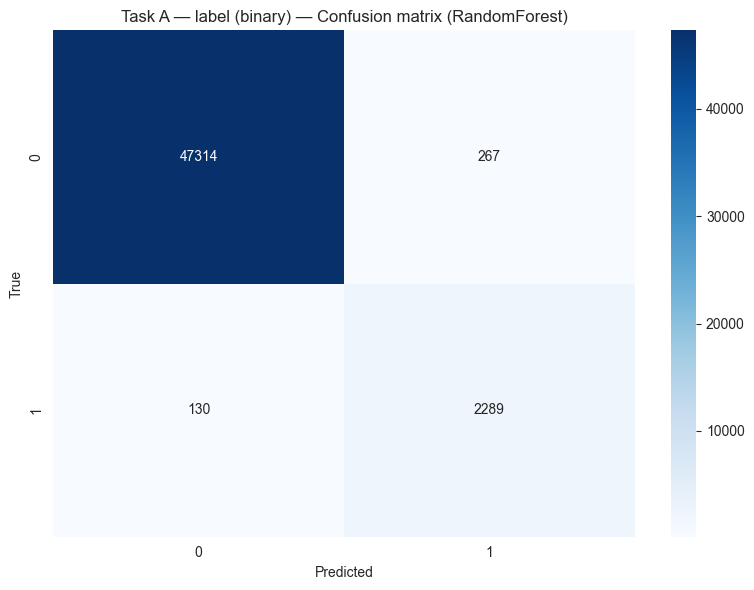


--- Task A — label (binary) | HistGradientBoosting | Test metrics ---
Accuracy: 0.98848
              precision    recall  f1-score   support

           0     0.9994    0.9885    0.9939     47581
           1     0.8140    0.9876    0.8924      2419

    accuracy                         0.9885     50000
   macro avg     0.9067    0.9881    0.9432     50000
weighted avg     0.9904    0.9885    0.9890     50000



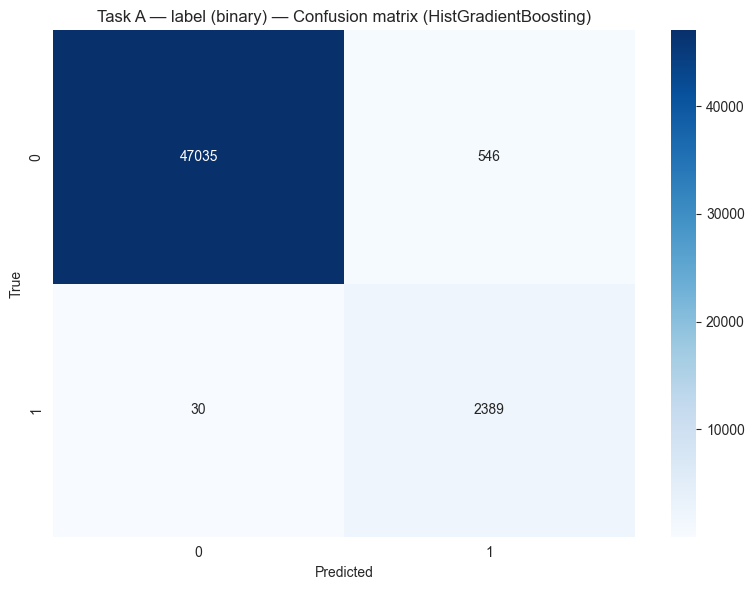

Saved model to: Processed_Dataset\model_label_best.joblib
Saved summary to: Processed_Dataset\model_label_summary.json


In [12]:
# Task A: binary classification
label_model_path = OUT_DIR / "model_label_best.joblib"
label_summary_path = OUT_DIR / "model_label_summary.json"

label_result = tune_compare_and_evaluate(
    X=X,
    y=y_label,
    task_name="Task A — label (binary)",
    scoring="f1",
    is_multiclass=False,
    out_model_path=label_model_path,
)

label_summary_path.write_text(
    json.dumps(
        {
            "task": "label",
            "selected_model": label_result["best_model_name"],
            "best_cv_score": label_result["best_cv_score"],
            "features": feature_cols,
        },
        indent=2,
    )  
)
print("Saved summary to:", label_summary_path)




=== Task B — attack_cat (multi-class): tuning Random Forest ===
Fitting 3 folds for each of 10 candidates, totalling 30 fits

=== Task B — attack_cat (multi-class): tuning Gradient Boosting ===
Fitting 3 folds for each of 10 candidates, totalling 30 fits

Best CV results:


,model,best_cv_score
1,HistGradientBoosting,0.595232
0,RandomForest,0.595220



Selected best model for Task B — attack_cat (multi-class): HistGradientBoosting

--- Task B — attack_cat (multi-class) | RandomForest | Test metrics ---
Accuracy: 0.97656
                precision    recall  f1-score   support

      Analysis     0.1125    0.3396    0.1690        53
      Backdoor     0.1293    0.3125    0.1829        48
           DoS     0.2870    0.2391    0.2609       138
      Exploits     0.7786    0.8343    0.8055       670
       Fuzzers     0.4391    0.8922    0.5885       529
       Generic     0.9772    0.8344    0.9002       616
        Normal     0.9997    0.9859    0.9928     47581
Reconnaissance     0.8338    0.8364    0.8351       324
     Shellcode     0.8250    0.8919    0.8571        37
         Worms     1.0000    0.2500    0.4000         4

      accuracy                         0.9766     50000
     macro avg     0.6382    0.6416    0.5992     50000
  weighted avg     0.9856    0.9766    0.9800     50000



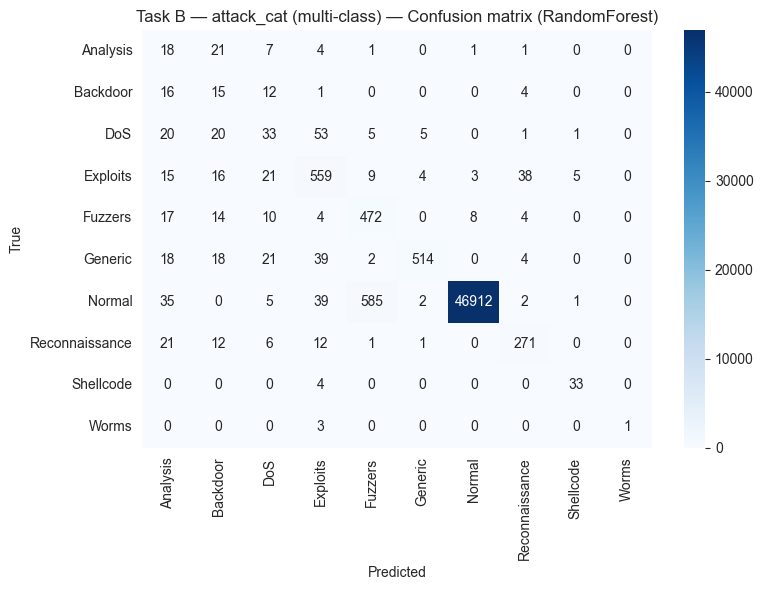


--- Task B — attack_cat (multi-class) | HistGradientBoosting | Test metrics ---
Accuracy: 0.97504
                precision    recall  f1-score   support

      Analysis     0.1398    0.4906    0.2176        53
      Backdoor     0.1477    0.4583    0.2234        48
           DoS     0.2568    0.2754    0.2657       138
      Exploits     0.7840    0.7478    0.7655       670
       Fuzzers     0.4364    0.9074    0.5893       529
       Generic     0.9538    0.8377    0.8920       616
        Normal     0.9999    0.9850    0.9924     47581
Reconnaissance     0.8354    0.8302    0.8328       324
     Shellcode     0.8205    0.8649    0.8421        37
         Worms     0.3333    0.2500    0.2857         4

      accuracy                         0.9750     50000
     macro avg     0.5708    0.6647    0.5906     50000
  weighted avg     0.9854    0.9750    0.9791     50000



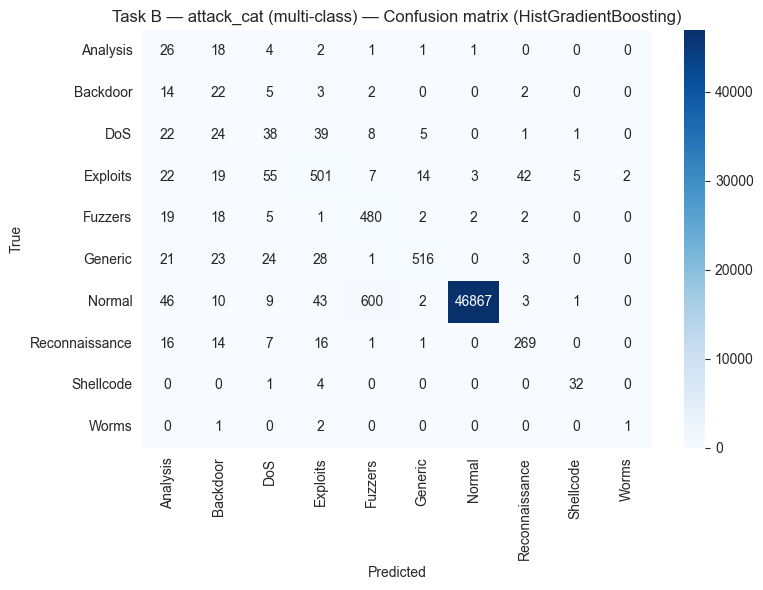

Saved model to: Processed_Dataset\model_attack_cat_best.joblib
Saved summary to: Processed_Dataset\model_attack_cat_summary.json


In [13]:
# Task B: multi-class classification
attack_model_path = OUT_DIR / "model_attack_cat_best.joblib"
attack_summary_path = OUT_DIR / "model_attack_cat_summary.json"

attack_result = tune_compare_and_evaluate(
    X=X,
    y=y_attack,
    task_name="Task B — attack_cat (multi-class)",
    scoring="f1_macro",
    is_multiclass=True,
    out_model_path=attack_model_path,
)

attack_summary_path.write_text(
    json.dumps(
        {
            "task": "attack_cat",
            "selected_model": attack_result["best_model_name"],
            "best_cv_score": attack_result["best_cv_score"],
            "classes": sorted(y_attack.unique().tolist()),
            "features": feature_cols,
        },
        indent=2,
    )
)
print("Saved summary to:", attack_summary_path)



### 6) Outputs recap

After running the notebook, you should have these artifacts in `training/Processed_Dataset/`:
- `UNSW_NB15_processed.csv` (cleaned + selected features + both targets)
- `selected_features.json`
- `dropped_features.json`
- `model_label_best.joblib` + `model_label_summary.json`
- `model_attack_cat_best.joblib` + `model_attack_cat_summary.json`

If you want faster runs, reduce `MAX_ROWS_FOR_MODELING` near the top.
